# TrunCat / TrunKitten Calibration Analysis

Assesses how well the OOF predicted probabilities match observed escape frequencies.

**Inputs:** `cv_predictions_with_ids.csv` for TrunCat and TrunKitten (must contain `oof_prob` and `y_true` columns).

**Outputs:**
- `outputs/calibration/calibration_summary.tsv` — Brier score, ECE, MCE, log loss per model
- `outputs/calibration/figs/calibration_overlay.png` (+ .pdf) — reliability diagram with both models
- `outputs/calibration/figs/prediction_histograms.png` (+ .pdf) — predicted probability distributions
- `outputs/calibration/figs/calibrated_overlay.png` (+ .pdf) — post-hoc isotonic-recalibrated curves (only if base calibration is poor)

**What gets computed:**
- **Reliability diagram**: bins predicted probabilities and plots mean predicted vs. observed frequency. Diagonal = perfectly calibrated.
- **Brier score**: mean squared error between predicted prob and true label. Lower = better. Combines calibration and discrimination.
- **ECE (Expected Calibration Error)**: weighted mean |predicted − observed| across bins. Pure calibration measure.
- **MCE (Maximum Calibration Error)**: worst-case bin gap.
- **Log loss**: standard probabilistic loss, sensitive to confident wrong predictions.

Bootstrap CIs use the same seed across both models so resampled indices are matched.

## 1. Configuration

In [1]:
from pathlib import Path

# --- Paths -----------------------------------------------------------------
BASE_DIR = Path("/Users/jschmidt3/NMDpredictionmodel")

TRUNCAT_OOF_PATH = BASE_DIR / "Model" / "TrunCat" / "results" / "cv_predictions_with_ids.csv"
TRUNKITTEN_OOF_PATH = BASE_DIR / "Model" / "TrunKitten" / "results" / "cv_predictions_with_ids.csv"

# --- Output --------------------------------------------------------------
OUTPUT_DIR = BASE_DIR / "Model" / "TrunCat" / "results" / "calibration"
FIG_DIR = OUTPUT_DIR / "figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Column names ----------------------------------------------------------
LABEL_COL = "y_true"
SCORE_COL = "oof_prob"

# --- Calibration settings --------------------------------------------------
N_BINS = 10                # number of bins for reliability diagram
BIN_STRATEGY = "quantile"  # "quantile" (equal-frequency) or "uniform" (equal-width)
N_BOOT = 1000
BOOT_SEED = 42

# --- Recalibration trigger -------------------------------------------------
# If ECE exceeds this, also fit isotonic recalibration via 5-fold CV and report
# post-recalibration metrics. CatBoost with log-loss is usually well-calibrated
# already, so this often won't trigger.
ECE_RECAL_THRESHOLD = 0.03

SAVE_OUTPUTS = True

print(f"TRUNCAT_OOF_PATH:    {TRUNCAT_OOF_PATH}")
print(f"TRUNKITTEN_OOF_PATH: {TRUNKITTEN_OOF_PATH}")
print(f"OUTPUT_DIR:          {OUTPUT_DIR}")

TRUNCAT_OOF_PATH:    /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/cv_predictions_with_ids.csv
TRUNKITTEN_OOF_PATH: /Users/jschmidt3/NMDpredictionmodel/Model/TrunKitten/results/cv_predictions_with_ids.csv
OUTPUT_DIR:          /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/calibration


## 2. Load OOF predictions

In [2]:
import pandas as pd
import numpy as np

def load_oof(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing OOF predictions: {path}")
    df = pd.read_csv(path, low_memory=False)
    for c in (LABEL_COL, SCORE_COL):
        if c not in df.columns:
            raise ValueError(f"{path.name} missing required column '{c}'. Has: {list(df.columns)}")
    df = df.dropna(subset=[LABEL_COL, SCORE_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    df[SCORE_COL] = df[SCORE_COL].astype(float)
    return df

tc = load_oof(TRUNCAT_OOF_PATH)
tk = load_oof(TRUNKITTEN_OOF_PATH)

print(f"TrunCat:    {len(tc):>6,} variants  | escape prevalence {tc[LABEL_COL].mean():.3f}")
print(f"TrunKitten: {len(tk):>6,} variants  | escape prevalence {tk[LABEL_COL].mean():.3f}")

for name, df in [("TrunCat", tc), ("TrunKitten", tk)]:
    s = df[SCORE_COL]
    print(f"  {name:11s}  prob range [{s.min():.4f}, {s.max():.4f}]  mean={s.mean():.4f}")
    if s.min() < 0 or s.max() > 1:
        print(f"  WARNING: {name} predictions fall outside [0, 1] — check that oof_prob is a probability, not a logit.")

TrunCat:     5,749 variants  | escape prevalence 0.455
TrunKitten:  5,749 variants  | escape prevalence 0.455
  TrunCat      prob range [0.0584, 0.9235]  mean=0.4529
  TrunKitten   prob range [0.0366, 0.9458]  mean=0.4542


## 3. Calibration metrics

Bootstrap CIs use a shared seed so the same resampled indices are applied to both models — interval differences are then directly comparable.

In [3]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.calibration import calibration_curve

def compute_ece_mce(y_true, y_prob, n_bins=10, strategy="quantile"):
    """Expected and Maximum Calibration Error.

    ECE = sum_b (n_b / N) * |mean(prob_b) - mean(y_true_b)|
    MCE = max_b |mean(prob_b) - mean(y_true_b)|
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        bin_edges = np.unique(np.quantile(y_prob, quantiles))
        if len(bin_edges) < 2:
            return np.nan, np.nan
    else:
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_ids = np.digitize(y_prob, bin_edges[1:-1])
    N = len(y_true)
    ece = 0.0
    mce = 0.0
    for b in range(len(bin_edges) - 1):
        mask = bin_ids == b
        n_b = mask.sum()
        if n_b == 0:
            continue
        gap = abs(y_prob[mask].mean() - y_true[mask].mean())
        ece += (n_b / N) * gap
        mce = max(mce, gap)
    return ece, mce


def calibration_metrics(y_true, y_prob, n_bins=10, strategy="quantile",
                        n_boot=1000, seed=42):
    """Point estimates + bootstrap CIs for Brier, ECE, MCE, log loss, AUC."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    point = {
        "n": len(y_true),
        "prevalence": float(y_true.mean()),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-15, 1 - 1e-15)),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }
    point["ece"], point["mce"] = compute_ece_mce(y_true, y_prob, n_bins=n_bins, strategy=strategy)

    rng = np.random.default_rng(seed)
    N = len(y_true)
    boot = {k: [] for k in ("brier", "log_loss", "ece", "mce", "roc_auc")}
    for _ in range(n_boot):
        idx = rng.integers(0, N, size=N)
        yt, yp = y_true[idx], y_prob[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue  # skip degenerate resamples
        boot["brier"].append(brier_score_loss(yt, yp))
        boot["log_loss"].append(log_loss(yt, np.clip(yp, 1e-15, 1 - 1e-15)))
        ece_b, mce_b = compute_ece_mce(yt, yp, n_bins=n_bins, strategy=strategy)
        boot["ece"].append(ece_b)
        boot["mce"].append(mce_b)
        boot["roc_auc"].append(roc_auc_score(yt, yp))

    out = dict(point)
    for k, vals in boot.items():
        if vals:
            lo, hi = np.percentile(vals, [2.5, 97.5])
            out[f"{k}_lo"] = lo
            out[f"{k}_hi"] = hi
        else:
            out[f"{k}_lo"] = np.nan
            out[f"{k}_hi"] = np.nan
    return out


metrics = {}
for name, df in [("TrunCat", tc), ("TrunKitten", tk)]:
    metrics[name] = calibration_metrics(
        df[LABEL_COL].values, df[SCORE_COL].values,
        n_bins=N_BINS, strategy=BIN_STRATEGY, n_boot=N_BOOT, seed=BOOT_SEED,
    )
    m = metrics[name]
    print(f"{name}")
    print(f"  Brier   = {m['brier']:.4f}  (95% CI {m['brier_lo']:.4f}-{m['brier_hi']:.4f})")
    print(f"  ECE     = {m['ece']:.4f}  (95% CI {m['ece_lo']:.4f}-{m['ece_hi']:.4f})")
    print(f"  MCE     = {m['mce']:.4f}  (95% CI {m['mce_lo']:.4f}-{m['mce_hi']:.4f})")
    print(f"  Log loss= {m['log_loss']:.4f}  (95% CI {m['log_loss_lo']:.4f}-{m['log_loss_hi']:.4f})")
    print(f"  ROC-AUC = {m['roc_auc']:.4f}  (95% CI {m['roc_auc_lo']:.4f}-{m['roc_auc_hi']:.4f})\n")

summary = pd.DataFrame([{"model": k, **v} for k, v in metrics.items()])
if SAVE_OUTPUTS:
    summary.to_csv(OUTPUT_DIR / "calibration_summary.tsv", sep="\t", index=False)
    print(f"[write] {OUTPUT_DIR / 'calibration_summary.tsv'}")
summary

TrunCat
  Brier   = 0.1877  (95% CI 0.1826-0.1923)
  ECE     = 0.0218  (95% CI 0.0172-0.0350)
  MCE     = 0.0380  (95% CI 0.0351-0.0831)
  Log loss= 0.5582  (95% CI 0.5467-0.5688)
  ROC-AUC = 0.7853  (95% CI 0.7747-0.7969)

TrunKitten
  Brier   = 0.1893  (95% CI 0.1842-0.1944)
  ECE     = 0.0224  (95% CI 0.0158-0.0344)
  MCE     = 0.0575  (95% CI 0.0355-0.0972)
  Log loss= 0.5622  (95% CI 0.5503-0.5740)
  ROC-AUC = 0.7806  (95% CI 0.7686-0.7923)

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/calibration/calibration_summary.tsv


,model,n,prevalence,brier,log_loss,roc_auc,ece,mce,brier_lo,brier_hi,log_loss_lo,log_loss_hi,ece_lo,ece_hi,mce_lo,mce_hi,roc_auc_lo,roc_auc_hi
0,TrunCat,5749,0.455384,0.187655,0.558219,0.785340,0.021825,0.037992,0.182572,0.192266,0.546729,0.568773,0.017174,0.034998,0.035123,0.083101,0.774705,0.796947
1,TrunKitten,5749,0.455384,0.189296,0.562166,0.780577,0.022360,0.057507,0.184150,0.194383,0.550287,0.573958,0.015767,0.034350,0.035473,0.097236,0.768587,0.792342


## 4. Reliability diagram

Each point = one bin. X = mean predicted probability in the bin, Y = actual fraction of positives in the bin. Diagonal = perfectly calibrated.

Above the diagonal → underconfident (model says 0.6, reality is 0.7).
Below the diagonal → overconfident (model says 0.6, reality is 0.5).

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/calibration/figs/calibration_overlay.png (+ .pdf)


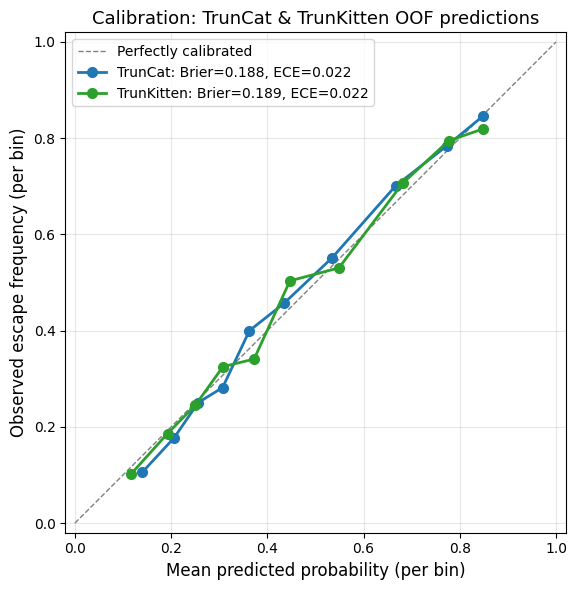

In [4]:
import matplotlib.pyplot as plt

MODEL_COLORS = {"TrunCat": "#1f77b4", "TrunKitten": "#2ca02c"}

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfectly calibrated")

for name, df in [("TrunCat", tc), ("TrunKitten", tk)]:
    y_true = df[LABEL_COL].values
    y_prob = df[SCORE_COL].values
    frac_pos, mean_pred = calibration_curve(
        y_true, y_prob, n_bins=N_BINS, strategy=BIN_STRATEGY,
    )
    m = metrics[name]
    label = (f"{name}: Brier={m['brier']:.3f}, ECE={m['ece']:.3f}")
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, markersize=7,
            color=MODEL_COLORS[name], label=label)

ax.set_xlabel("Mean predicted probability (per bin)", fontsize=12)
ax.set_ylabel("Observed escape frequency (per bin)", fontsize=12)
ax.set_title("Calibration: TrunCat & TrunKitten OOF predictions", fontsize=13)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()

if SAVE_OUTPUTS:
    fig.savefig(FIG_DIR / "calibration_overlay.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "calibration_overlay.pdf", bbox_inches="tight")
    print(f"[write] {FIG_DIR / 'calibration_overlay.png'} (+ .pdf)")
plt.show()

## 5. Predicted probability histograms

Reliability diagrams can mislead if a bin only has a handful of points. The histogram shows where each model's predictions actually concentrate.

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/calibration/figs/prediction_histograms.png (+ .pdf)


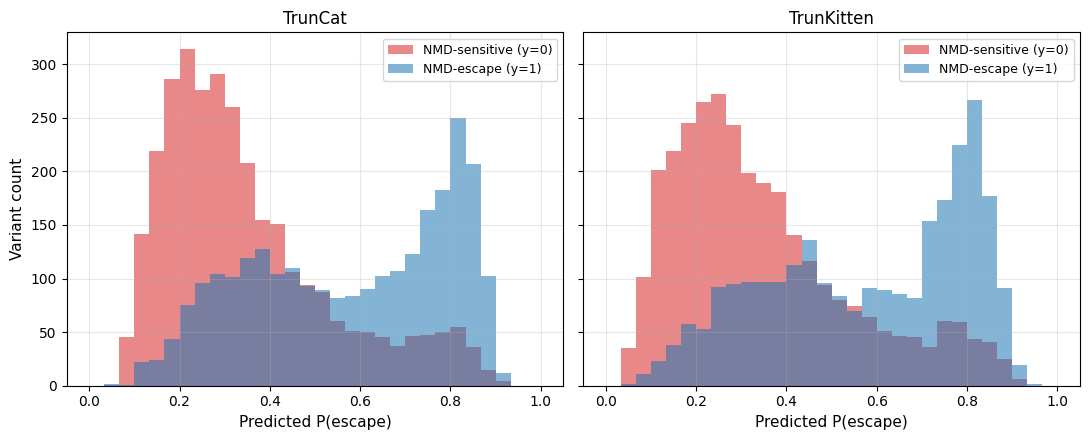

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, (name, df) in zip(axes, [("TrunCat", tc), ("TrunKitten", tk)]):
    y_true = df[LABEL_COL].values
    y_prob = df[SCORE_COL].values
    bins = np.linspace(0, 1, 31)
    ax.hist(y_prob[y_true == 0], bins=bins, alpha=0.55, label="NMD-sensitive (y=0)", color="#d62728")
    ax.hist(y_prob[y_true == 1], bins=bins, alpha=0.55, label="NMD-escape (y=1)", color="#1f77b4")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predicted P(escape)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Variant count", fontsize=11)
plt.tight_layout()

if SAVE_OUTPUTS:
    fig.savefig(FIG_DIR / "prediction_histograms.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "prediction_histograms.pdf", bbox_inches="tight")
    print(f"[write] {FIG_DIR / 'prediction_histograms.png'} (+ .pdf)")
plt.show()

## 6. (Optional) Post-hoc isotonic recalibration

Only runs if ECE exceeds `ECE_RECAL_THRESHOLD`. Uses 5-fold CV to fit isotonic regression on the OOF predictions and produces recalibrated probabilities, with their own metrics and reliability diagram. This avoids overfitting the calibrator to the same data it's evaluated on.

If TrunCat/TrunKitten are already well-calibrated (CatBoost with log-loss usually is), this section is a no-op.

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold

models_needing_recal = [name for name, m in metrics.items() if m["ece"] > ECE_RECAL_THRESHOLD]

if not models_needing_recal:
    print(f"All models have ECE <= {ECE_RECAL_THRESHOLD}; skipping isotonic recalibration.")
else:
    print(f"Recalibrating: {models_needing_recal}")

    def cv_isotonic_recalibrate(y_true, y_prob, n_folds=5, seed=42):
        """Fold-aware isotonic recalibration: each variant gets a recalibrated
        probability from a calibrator fit on the *other* folds."""
        y_true = np.asarray(y_true)
        y_prob = np.asarray(y_prob)
        recal = np.zeros_like(y_prob)
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        for train_idx, test_idx in skf.split(y_prob, y_true):
            iso = IsotonicRegression(out_of_bounds="clip")
            iso.fit(y_prob[train_idx], y_true[train_idx])
            recal[test_idx] = iso.predict(y_prob[test_idx])
        return recal

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfectly calibrated")

    recal_metrics = {}
    for name in models_needing_recal:
        df = tc if name == "TrunCat" else tk
        y_true = df[LABEL_COL].values
        y_prob_recal = cv_isotonic_recalibrate(y_true, df[SCORE_COL].values, seed=BOOT_SEED)

        recal_metrics[name] = calibration_metrics(
            y_true, y_prob_recal,
            n_bins=N_BINS, strategy=BIN_STRATEGY, n_boot=N_BOOT, seed=BOOT_SEED,
        )
        m = recal_metrics[name]
        print(f"{name} (recalibrated):")
        print(f"  Brier = {m['brier']:.4f}  ECE = {m['ece']:.4f}  ROC-AUC = {m['roc_auc']:.4f}")

        frac_pos, mean_pred = calibration_curve(
            y_true, y_prob_recal, n_bins=N_BINS, strategy=BIN_STRATEGY,
        )
        ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, markersize=7,
                color=MODEL_COLORS[name],
                label=f"{name} (recal): Brier={m['brier']:.3f}, ECE={m['ece']:.3f}")

    ax.set_xlabel("Mean predicted probability (per bin)", fontsize=12)
    ax.set_ylabel("Observed escape frequency (per bin)", fontsize=12)
    ax.set_title("Calibration after isotonic recalibration (5-fold CV)", fontsize=13)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=10)
    plt.tight_layout()

    if SAVE_OUTPUTS:
        fig.savefig(FIG_DIR / "calibrated_overlay.png", dpi=300, bbox_inches="tight")
        fig.savefig(FIG_DIR / "calibrated_overlay.pdf", bbox_inches="tight")
        recal_summary = pd.DataFrame([{"model": f"{k}_recalibrated", **v} for k, v in recal_metrics.items()])
        recal_summary.to_csv(OUTPUT_DIR / "calibration_summary_recalibrated.tsv", sep="\t", index=False)
        print(f"[write] {FIG_DIR / 'calibrated_overlay.png'} (+ .pdf)")
        print(f"[write] {OUTPUT_DIR / 'calibration_summary_recalibrated.tsv'}")
    plt.show()

## 7. Quick interpretation guide

**Brier score** is the workhorse number. For binary classification with prevalence ~0.5, a useless model (always predicting prevalence) gets Brier ≈ 0.25. Lower is better. TrunCat/TrunKitten in the 0.15–0.20 range would be reasonable for a model with AUC ~0.78.

**ECE** is the cleanest single calibration number. Rough guide:
- < 0.02: excellent calibration, defensible to claim "calibrated" without hedging
- 0.02–0.05: good, acceptable to claim with the calibration plot as evidence
- 0.05–0.10: noticeable miscalibration; isotonic recalibration usually helps
- > 0.10: significantly miscalibrated; recalibrate before claiming calibrated probabilities

**MCE** flags the worst-bin gap. A high MCE with low ECE means most predictions are fine but one prob range is off — useful for the discussion if it falls in a clinically meaningful range (e.g., the borderline 0.4–0.6 zone for VUS).

**Reliability shape interpretation:**
- Curve consistently above diagonal → underconfident, predictions compressed toward 0.5
- Curve consistently below diagonal → overconfident, predictions pushed toward 0/1
- S-shape with crossover at 0.5 → typical sigmoid output, isotonic regression usually fixes it

**For the manuscript:**
If TrunCat ECE < 0.05 and the reliability curve hugs the diagonal, the abstract claim about calibrated predictions is defensible — supplementary figure showing the calibration plot and the Brier/ECE values. If miscalibrated, either drop the calibration claim or report results from the isotonic-recalibrated model with the recalibration step described in methods.